# Notebook 2 : Feature Extraction ed Exploratory Data Analysis (EDA) - Silver Layer

**Progetto:** Premier League Event Data 2020-21  
**Input:** `data/processed/dataset_clean.parquet` (prodotto dal NB1)  
**Output:** `data/processed/features.parquet` (usato dal NB3)

Il cuore di questo notebook è l'**aggregazione**: trasformiamo il dataset grezzo da ~607k righe (una per evento) a 606k con la pulizia e infine 760 righe (una per squadra per partita), secondo lo schema:

```
Dataset grezzo:          Dataset aggregato:
607k righe               760 righe
1 riga = 1 evento        1 riga = 1 squadra in 1 partita
                         (380 partite × 2 squadre)
```

<a href="https://colab.research.google.com/github/Frestka/Mining_Premier_League/blob/main/notebooks/Feature_extraction_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup e Caricamento

In [ ]:
# Rilevamento automatico ambiente:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os, sys
    from pathlib import Path

    REPO_NAME = "Mining_Premier_League"
    REPO_URL  = "https://github.com/Frestka/Mining_Premier_League.git"

    os.chdir("/content")
    if not os.path.exists(REPO_NAME):
        !git clone -q {REPO_URL}
    os.chdir(REPO_NAME)
    sys.path.insert(0, os.path.abspath("."))

    !git fetch -q origin
    !git checkout -q origin/main
    !pip install -q -r requirements.txt
    Path("data/processed").mkdir(parents=True, exist_ok=True)

    import gdown
    FILES = {
        "data/processed/dataset_clean.parquet": "1gCE4B6r1wngsEorSU-7WMsGKWbHwUYwd",  # Silver layer
    }

    for path, file_id in FILES.items():
        if not os.path.exists(path):
            print(f"Download {path}...")
            gdown.download(id=file_id, output=path, quiet=False, fuzzy=True)
        else:
            print(f"Gia presente, skip -> {path}")

    print(f"\nSetup Colab completato. Cartella: {os.getcwd()}")

else:
    print("Ambiente locale rilevato: setup Colab saltato automaticamente.")

In [ ]:
import sys, os
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

def setup_project():
    root = Path.cwd()
    while not (root / 'requirements.txt').exists() and root.parent != root:
        root = root.parent
    if not (root / 'requirements.txt').exists():
        raise RuntimeError(
            "File requirements.txt non trovato. Su Colab esegui prima la cella Setup Colab. "
            "In locale apri il notebook dalla root del repo o da notebooks/."
        )
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    os.chdir(root)
    return root

PROJECT_ROOT = setup_project()
print(f'Project root: {PROJECT_ROOT}')

sns.set_theme(style='whitegrid', palette='tab10')

df = pd.read_parquet('data/processed/dataset_clean.parquet')
print(f'Dataset Silver caricato con successo!')
print(f'Dimensioni: {df.shape[0]:,} righe x {df.shape[1]} colonne')

## Derivazione del Target (Win, Draw, Loss)

Avendo già a disposizione il `match_id` e un dataset pulito (dal Notebook 1), procediamo al calcolo dei goal segnati e subiti da ciascuna squadra.


In [ ]:
df_game = df.copy()
n_matches = df_game["match_id"].nunique()
print(f"Partite identificate: {n_matches}  (attese: 380 per PL 2020-21)\n")

# Sqaudre con almeno un goal per match
goals_df = (
    df_game[df_game["type_displayName"] == "Goal"]
    .groupby(["match_id", "teamId"])
    .size()
    .reset_index(name="goals_scored")
)

# Matrice completa match x team (include squadre con 0 goal)
all_pairs = (
    df_game.groupby(["match_id", "teamId"])
    .size()
    .reset_index(name="total_events")[["match_id", "teamId"]]
)

results_df = all_pairs.merge(goals_df, on=["match_id", "teamId"], how="left")
results_df["goals_scored"] = results_df["goals_scored"].fillna(0).astype(int)

# Goal subiti = totale gol del match - gol segnati
total_goals = results_df.groupby("match_id")["goals_scored"].transform("sum")
results_df["goals_conceded"] = total_goals - results_df["goals_scored"]
opp = results_df.copy()

def outcome(row):
    if   row["goals_scored"] > row["goals_conceded"]: return "Win"
    elif row["goals_scored"] < row["goals_conceded"]: return "Loss"
    else:                                              return "Draw"

opp["outcome"] = opp.apply(outcome, axis=1)

print("\nDistribuzione outcome (per team-match):")
print(opp["outcome"].value_counts())

avg_goals = opp.groupby("match_id")["goals_scored"].sum().mean()
print(f"\nMedia goal per partita: {avg_goals:.2f}")

n_partite_uniche = opp['match_id'].nunique()
print(f"\nPartite uniche nel dataset: {n_partite_uniche}")

expected_rows = n_partite_uniche * 2
print(f"Righe attese (2 per partita): {expected_rows}")
print(f"Righe attuali nel dataset: {len(opp)}")

duplicati = opp.duplicated(subset=['match_id', 'teamId']).sum()
print(f"Righe duplicate (stessa partita e stessa squadra): {duplicati}")

if len(opp) != expected_rows:
    print("\nATTENZIONE: Il numero di righe non corrisponde al doppio delle partite!")
else:
    print("\nTUTTO OK: Hai esattamente due righe per ogni partita.")

In [ ]:
#Flag di successo prima del groupby
if "outcomeType_displayName" in df_game.columns:
    df_game["is_successful"] = df_game["outcomeType_displayName"] == "Successful"

def extract_features(grp):
    """
    Estrae le feature tattiche e spaziali per squadra-partita.
    Previene il Data Leakage ignorando i gol.
    """
    total_events = len(grp)
    minutes_played = grp["minute"].clip(upper=120).max() - grp["minute"].clip(upper=120).min()
    minutes_played = max(minutes_played, 1)

    # Sub-dataframe
    passes = grp[grp["type_displayName"] == "Pass"]
    shots = grp[(grp.get("isShot", False) == True) & (grp.get("isGoal", False) == False)]
    goals = grp[grp["type_displayName"] == "Goal"]
    tackles = grp[grp["type_displayName"] == "Tackle"]
    fouls = grp[grp["type_displayName"] == "Foul"]
    corners = grp[grp["type_displayName"] == "CornerAwarded"]
    aerials = grp[grp["type_displayName"] == "Aerial"]
    clearances = grp[grp["type_displayName"] == "Clearance"]
    intercepts = grp[grp["type_displayName"] == "Interception"]
    takeons = grp[grp["type_displayName"] == "TakeOn"]
    recoveries = grp[grp["type_displayName"] == "BallRecovery"]

    ft = grp[grp["period_displayName"] == "FirstHalf"]

    def safe_rate(num, den):
        return num / den if den > 0 else 0.0

    # Coordinate Spaziali
    avg_x = grp["x"].mean()
    avg_y = grp["y"].mean()
    avg_pass_end_x = passes["endX"].mean() if "endX" in passes.columns else np.nan

    # Field Tilt
    offensive_third = grp[grp['x'] > 66.6]
    field_tilt = len(offensive_third) / total_events if total_events > 0 else 0.0

    # Gestione Cartellini
    n_yellow = grp[grp['cardType_displayName'] == 'Yellow'].shape[0]
    red_events = grp[grp['cardType_displayName'].isin(['Red', 'SecondYellow'])]
    n_red = red_events['playerId'].nunique() if 'playerId' in red_events.columns else red_events.shape[0]

    # --- FUNZIONI HELPER ---
    def safe_sum(col_name):
        return grp[col_name].sum() if col_name in grp.columns else 0

    def safe_mean(col_name):
        return grp[col_name].mean() if col_name in grp.columns else np.nan


    return pd.Series({
        # Metriche Volume Base
        "n_passes": len(passes),
        "n_shots_no_goal": len(shots),
        "n_tackles": len(tackles),
        "n_fouls": len(fouls),
        "n_corners": len(corners),
        "n_aerials": len(aerials),
        "n_clearances": len(clearances),
        "n_interceptions": len(intercepts),
        "n_takeons": len(takeons),
        "n_ball_recoveries": len(recoveries),
        "events_per_minute": total_events / minutes_played,
        "first_half_ratio":  safe_rate(len(ft), total_events),

        # Metriche Tattiche Avanzate (dai Qualifiers)
        "n_longballs": safe_sum('is_longball'),
        "n_crosses": safe_sum('is_cross'),
        "n_throughballs": safe_sum('is_throughball'),
        "n_accurate_keypasses": (passes["is_keypass"] & passes["is_successful"]).sum() if ("is_keypass" in passes.columns and "is_successful" in passes.columns) else 0,
        "n_fastbreaks": safe_sum('is_fastbreak'),

        # Somme aggregate
        "n_big_chances": safe_sum('is_bigchance') + safe_sum('is_bigchancecreated'),
        "n_blocks": safe_sum('is_blocked') + safe_sum('is_outfielderblock') + safe_sum('is_sixyardblock'),

        # Metriche Spaziali e Dominio Territoriale
        "avg_x": avg_x,
        "avg_y": avg_y,
        "avg_pass_end_x": avg_pass_end_x,
        "field_tilt": field_tilt,
        "n_passes_offensive_third": len(offensive_third[offensive_third['type_displayName'] == 'Pass']),
        "avg_pass_length": safe_mean('pass_length'),
        "avg_goal_mouth_z": safe_mean('goalMouthZ'),
        "set_piece_ratio": safe_rate((safe_sum('is_fromcorner') + safe_sum('is_setpiece')), len(shots)),

        # Eventi disciplinari
        "n_yellow_cards": n_yellow,
        "n_red_cards": n_red,

        # Ratei di Efficienza
        "pass_success_rate": safe_rate(passes["is_successful"].sum(), len(passes)) if "is_successful" in passes.columns else np.nan,
        "tackle_success_rate": safe_rate(tackles["is_successful"].sum(), len(tackles)) if "is_successful" in tackles.columns else np.nan,
        "aerial_success_rate": safe_rate(aerials["is_successful"].sum(), len(aerials)) if "is_successful" in aerials.columns else np.nan,
        "takeon_success_rate": safe_rate(takeons["is_successful"].sum(), len(takeons)) if "is_successful" in takeons.columns else np.nan,
    })

print("Funzione 'extract_features' definita con successo.")



## Feature Engineering


### Co-occorrenza degli eventi (Livello Micro → Macro)
Un'azione tecnica vale solo se completata, perciò abbiamo ingegnerizzato la feature **`n_accurate_keypasses`** combinando `is_keypass` con `outcomeType == 'Successful'`, fondendo le variabili binarie a livello di singolo evento prima dell'aggregazione di partita. Per eliminare la **multicollinearità** e ridondanza nel modello, abbiamo rimosso la variabile originale `n_keypasses` (il "parent"), costringendolo a valutare solo la qualità pura del gesto tecnico. 

### Sfruttamento della struttura di gruppi (Livello Macro — Confronto con il Rivale)
Ogni `match_id` raggruppa esattamente 2 righe (le 2 squadre sfidanti). Abbiamo sfruttato questa struttura per costruire **feature relazionali di dominanza**: `pass_dominance` e `big_chance_dominance`. Un valore vicino a 1.0 indica dominanza assoluta; 0.5 indica parità.


In [ ]:
import time

print("Avvio aggregazione feature tattiche. Attendere...")
start_time = time.time()

# Esecuzione dell'aggregazione
features_raw = (
    df_game.groupby(["match_id", "teamId"], group_keys=False)
    .apply(extract_features, include_groups=False)
    .reset_index()
)

# Uniamo il dataset con il target (esito e goal)
features = features_raw.merge(
    opp[["match_id", "teamId", "goals_scored", "goals_conceded", "outcome"]],
    on=["match_id", "teamId"],
    how="inner"
)

# Sostituiamo eventuali NaN con 0
features = features.fillna(0)

# ── Feature Relazionali di Dominanza
features['pass_dominance'] = features.groupby('match_id')['n_passes'].transform(
    lambda x: x / x.sum() if x.sum() > 0 else 0.5
)
features['big_chance_dominance'] = features.groupby('match_id')['n_big_chances'].transform(
    lambda x: x / x.sum() if x.sum() > 0 else 0.5
)

print(" Feature relazionali aggiunte: pass_dominance, big_chance_dominance")
print(f"   Verifica: {features[['match_id','pass_dominance','big_chance_dominance']].head(4).to_string()}")

end_time = time.time()
print(f"Aggregazione completata in {end_time - start_time:.2f} secondi.")
print(f"Dimensioni dataset Gold: {features.shape[0]} righe × {features.shape[1]} colonne (Attesi: 760 righe)")

FEATURE_COLS = [c for c in features.columns
                if c not in ["match_id", "teamId", "goals_scored",
                             "goals_conceded", "outcome"]]

print(f"\nColonne feature pronte per l'EDA e il ML: {len(FEATURE_COLS)}")
print("\nAnteprima delle nuove metriche estratte:")
print(features[['teamId', 'n_passes', 'n_longballs', 'n_big_chances', 'n_fastbreaks', 'pass_success_rate', 'outcome']].head())


class_means = features.groupby("outcome")[FEATURE_COLS].mean()
global_std  = features[FEATURE_COLS].std()

print("--- Media per classe (Win / Draw / Loss) ---")
print(class_means[['n_passes', 'n_big_chances', 'n_accurate_keypasses', 'avg_x']].round(2).T.to_string())


diff_win_loss = (class_means.loc["Win"] - class_means.loc["Loss"]).abs()


Avvio aggregazione feature tattiche. Attendere...
 Feature relazionali aggiunte: pass_dominance, big_chance_dominance
   Verifica:    match_id  pass_dominance  big_chance_dominance
0         1        0.618367                   0.4
1         1        0.381633                   0.6
2         2        0.313646                   0.0
3         2        0.686354                   1.0
Aggregazione completata in 18.83 secondi.
Dimensioni dataset Gold: 760 righe × 40 colonne (Attesi: 760 righe)

Colonne feature pronte per l'EDA e il ML: 35

Anteprima delle nuove metriche estratte:
   teamId  n_passes  n_longballs  n_big_chances  n_fastbreaks  \
0      32     606.0         61.0            2.0           1.0   
1     184     374.0         94.0            3.0           0.0   
2      24     308.0         68.0            0.0           2.0   
3     167     674.0         53.0            4.0           1.0   
4      18     638.0         88.0            4.0           0.0   

   pass_success_rate outcome  

### Recap: Il Dataset Finale 

Il risultato della nostra aggregazione è un dataset di **760 righe e 40 colonne** (`features.parquet`).

La maggior parte delle **35 feature tattiche** (conteggi di passaggi, tackle, falli, coordinate spaziali, ratei di efficienza) sono state già descritte nel Notebook 1 ([Data_Cleaning_and_Understanding.ipynb](Data_Cleaning_and_Understanding.ipynb)) durante l'interpretazione delle colonne grezze.

In questo notebook abbiamo aggiunto **nuove feature ingegnerizzate** attraverso due strategie distinte:

#### **Feature Estratte dalla Colonna `qualifiers` (6 feature)**
Dopo il parsing del JSON `qualifiers` effettuato nel Notebook 1, in questa sezione abbiamo estratto le seguenti metriche tattiche avanzate:
- `n_longballs`: Passaggi lunghi tentati
- `n_crosses`: Cross effettuati verso l'area
- `n_throughballs`: Passaggi filtranti (tagliano le linee difensive)
- `n_fastbreaks`: Azioni veloci di contropiede
- `n_big_chances`: Grandi occasioni prodotte
- `n_blocks`: Tiri avversari bloccati fisicamente

#### **Feature Ingegnerizzate**
- `n_accurate_keypasses`: di cusi discusso nelle sezioni precedenti.

#### **Feature Relazionali — Dominanza**
Sfruttano la struttura a gruppi del dataset: ogni `match_id` raggruppa esattamente 2 squadre (i 2 contendenti della stessa partita).
- `pass_dominance`: Rapporto fra i passaggi della squadra e il totale dei passaggi nel match (1.0 = dominio totale; 0.5 = parità)
- `big_chance_dominance`: Rapporto fra le grandi occasioni della squadra e il totale nel match

**Sommario**:
- `35 feature tattiche totali`: 6 da qualifiers + 1 fusa + 2 relazionali + 26 base (già descritte nel NB1)
- `5 feature Identificativi/Target`: match_id, teamId, goals_scored, goals_conceded, outcome

## Exploratory Data Analysis (EDA)

### Analisi degli Outlier Globali

Per identificare la presenza di valori anomali (outlier) all'interno del dataset, abbiamo applicato il **metodo dell'Intervallo Interquartile (IQR)** il quale si basa sui percentili della distribuzione. Le formule utilizzate per definire le soglie di accettabilità sono le seguenti:
1. **Primo Quartile ($Q_1$):** Il 25° percentile dei dati.
2. **Terzo Quartile ($Q_3$):** Il 75° percentile dei dati.
3. **Intervallo Interquartile ($IQR$):** La differenza tra i due quartili, che rappresenta il 50% centrale della distribuzione.
   $$IQR = Q_3 - Q_1$$
4. **Soglia Inferiore (Lower Bound):** 
   $$Lower\ Bound = Q_1 - 1.5 \times IQR$$
5. **Soglia Superiore (Upper Bound):** 
   $$Upper\ Bound = Q_3 + 1.5 \times IQR$$
Qualsiasi valore che ricade al di sotto della soglia inferiore o al di sopra della soglia superiore viene matematicamente classificato come outlier.

In [17]:
outlier_stats = []

# Calcoliamo gli outlier per TUTTE le feature (FEATURE_COLS)
for feat in FEATURE_COLS:
    Q1 = features[feat].quantile(0.25)
    Q3 = features[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = features[(features[feat] < lower_bound) | (features[feat] > upper_bound)]
    
    outlier_stats.append({
        'Feature': feat,
        'N. Outlier Globali': len(outliers),
        '% Outlier': (len(outliers) / len(features)) * 100
        #'Limite Inferiore (Min)': round(lower_bound, 2),
        #'Limite Superiore (Max)': round(upper_bound, 2)  
    })


outlier_df = pd.DataFrame(outlier_stats).sort_values(by='% Outlier', ascending=False)

# Formattiamo la colonna percentuale per una visualizzazione migliore
outlier_df['% Outlier'] = outlier_df['% Outlier'].map("{:.1f}%".format)

print("Analisi Outlier Globali (Metodo IQR 1.5) - Tutte le feature:\n")
display(outlier_df)


Analisi Outlier Globali (Metodo IQR 1.5) - Tutte le feature:



,Feature,N. Outlier Globali,% Outlier
28,n_red_cards,45,5.9%
27,n_yellow_cards,34,4.5%
14,n_throughballs,33,4.3%
16,n_fastbreaks,28,3.7%
23,n_passes_offensive_third,21,2.8%
25,avg_goal_mouth_z,20,2.6%
30,tackle_success_rate,19,2.5%
26,set_piece_ratio,17,2.2%
4,n_corners,16,2.1%
15,n_accurate_keypasses,14,1.8%


### Boxplot - 9 Feature piu discriminanti

#### Criterio di Selezione delle Feature (Effect Size)

Per identificare le metriche più discriminanti senza farci influenzare dalla scala di grandezza dei dati, abbiamo utilizzato la seguente formula di standardizzazione:

$$\text{Discriminanza} = \frac{|\text{Mediana}_{\text{Win}} - \text{Mediana}_{\text{Loss}}|}{\sigma_{\text{globale}}}$$

Dove:
* $|\text{Mediana}_{\text{Win}} - \text{Mediana}_{\text{Loss}}|$ rappresenta la distanza assoluta tra le prestazioni della partita tipica vinta e di quella persa (approccio robusto agli outlier).
* $\sigma_{\text{globale}}$ è la deviazione standard dell'intera colonna, utilizzata come fattore di normalizzazione per isolare il segnale dal rumore di fondo.

TABELLA RIEPILOGATIVA - TOP 9 FEATURE PIÙ DISCRIMINANTI (WIN vs LOSS):



,Median_Win,Median_Loss,Global_Std,Effect_Size
big_chance_dominance,0.696,0.304,0.333,1.180
n_throughballs,1.000,0.000,0.882,1.134
n_yellow_cards,1.000,2.000,1.151,0.869
n_accurate_keypasses,10.000,7.000,4.188,0.716
n_big_chances,4.000,2.000,2.806,0.713
first_half_ratio,0.507,0.483,0.037,0.663
n_clearances,20.000,16.000,8.824,0.453
n_crosses,16.000,19.000,8.105,0.370
pass_success_rate,0.805,0.781,0.072,0.336


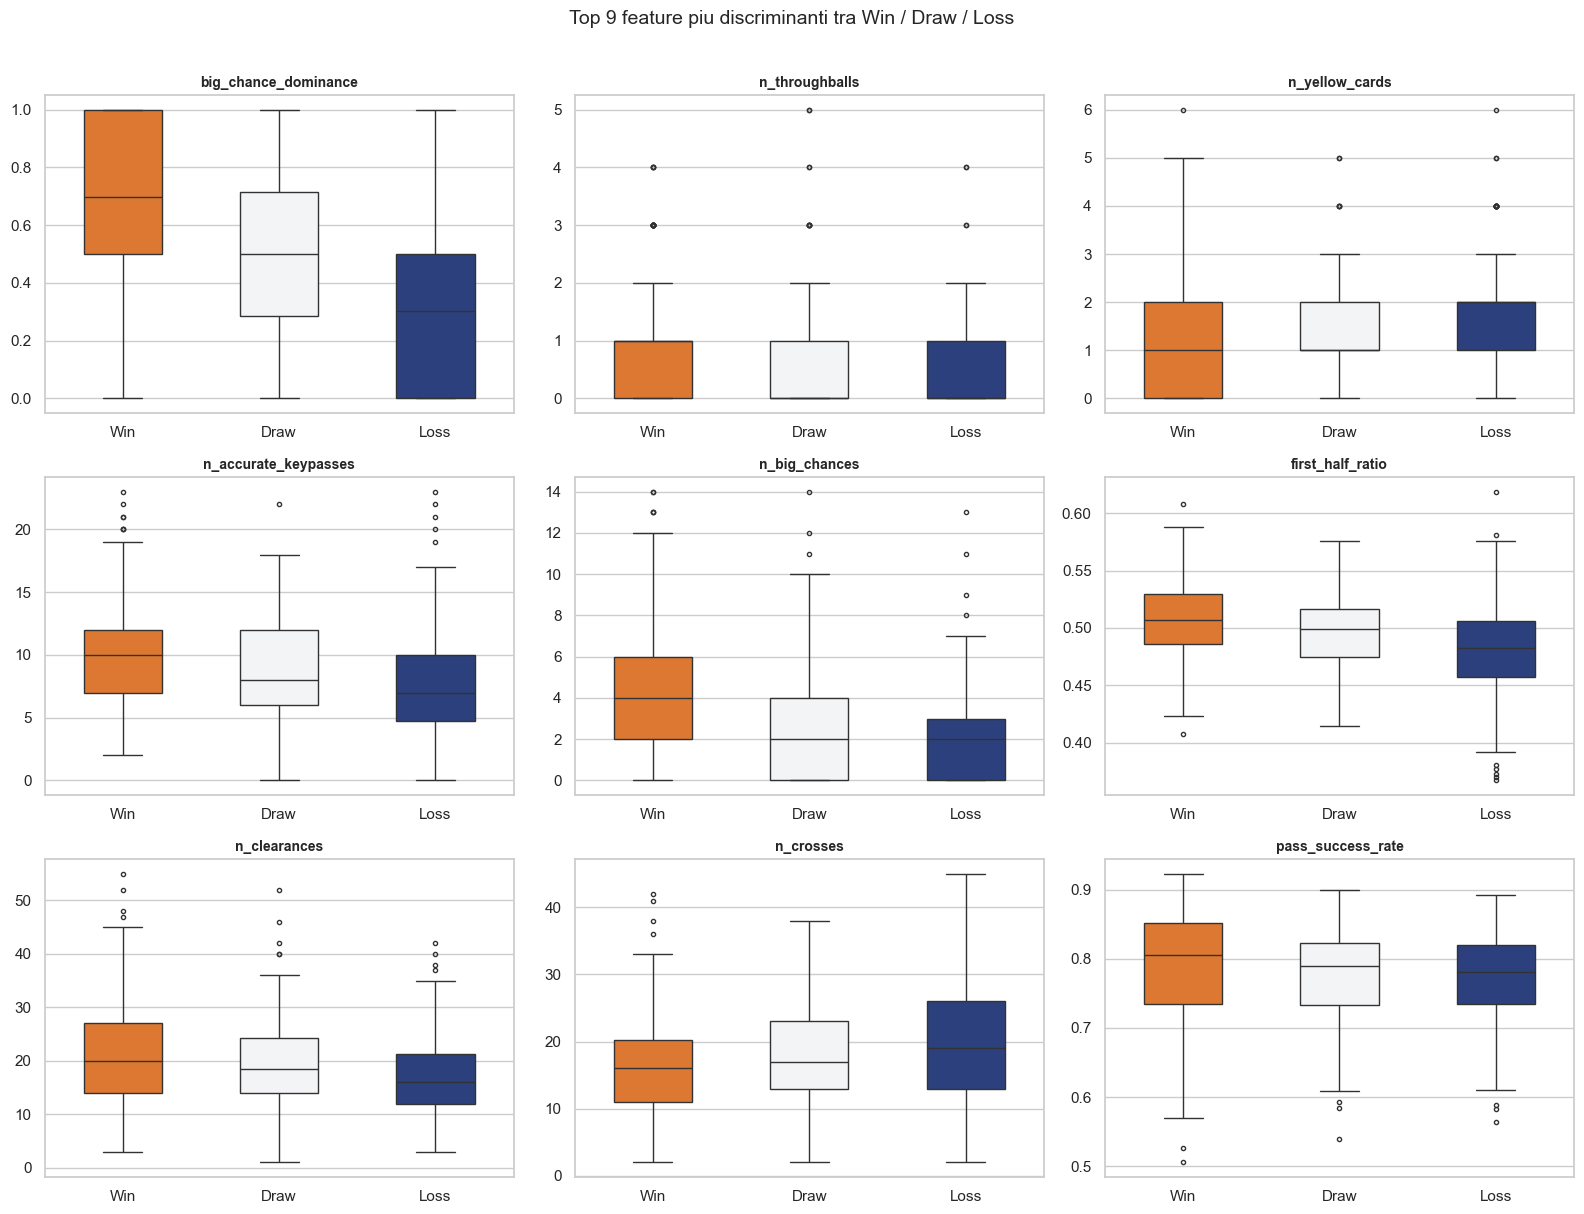

In [21]:
OUTCOME_ORDER = ["Win", "Draw", "Loss"]
PALETTE = {"Win": "#F97316", "Draw": "#F3F4F6", "Loss": "#1E3A8A"}

class_medians = features.groupby("outcome")[FEATURE_COLS].median()

# Effect Size (Distanza delle mediane normalizzata per sigma)
effect_size = (class_medians.loc["Win"] - class_medians.loc["Loss"]).abs() / global_std

# Estrazione 9 feature più discriminanti
top_features = effect_size.sort_values(ascending=False).head(9).index.tolist()

# --- STAMPA TABELLA RIEPILOGATIVA ---
summary_df = pd.DataFrame({
    'Median_Win': class_medians.loc['Win', top_features],
    'Median_Loss': class_medians.loc['Loss', top_features],
    'Global_Std': global_std[top_features],
    'Effect_Size': effect_size[top_features]
})

print("TABELLA RIEPILOGATIVA - TOP 9 FEATURE PIÙ DISCRIMINANTI (WIN vs LOSS):\n")
display(summary_df.round(3))
print("\n" + "="*80 + "\n")

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, feat in zip(axes.flatten(), top_features):
    sns.boxplot(data=features, x="outcome", y=feat,
                order=OUTCOME_ORDER, palette=PALETTE,
                ax=ax, width=0.5, fliersize=3)
    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("")

plt.suptitle("Top 9 feature piu discriminanti tra Win / Draw / Loss",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Medie per classe e analisi della significatività

Confrontiamo le medie di ogni feature tra le classi Win, Draw e Loss. Una feature è considerata **discriminante** se la differenza assoluta tra il valore medio della classe Win e quello della classe Loss supera **1 deviazione standard globale** (calcolata sull'intero dataset, non per classe).

In [18]:
class_means = features.groupby("outcome")[FEATURE_COLS].mean()
global_std  = features[FEATURE_COLS].std()

print("--- Media per classe (Win / Draw / Loss) ---")
print(class_means.round(3).T.to_string())

diff_win_loss = (class_means.loc["Win"] - class_means.loc["Loss"]).abs()

print("\n--- Analisi significatività (> 1sigma) ---")
pairs = [("Win", "Loss"), ("Win", "Draw"), ("Draw", "Loss")]
for c1, c2 in pairs:
    diff = (class_means.loc[c1] - class_means.loc[c2]).abs()
    significant = diff[diff > global_std]
    print(f"\n--- {c1} vs {c2} ---")
    print(f"Feature significative (> 1σ): {len(significant)}")
    for feat in diff.sort_values(ascending=False).head(10).index:
        sd = global_std[feat]
        marker = "[SÌ]" if feat in significant.index else "[NO]"
        print(f"{marker} {feat:<26} {c1}={class_means.loc[c1, feat]:.2f}  "
              f"{c2}={class_means.loc[c2, feat]:.2f}  "
              f"|diff|={diff[feat]:.2f}  sigma={sd:.2f}  -> {diff[feat]/sd:.1f}sigma")


--- Media per classe (Win / Draw / Loss) ---
outcome                      Draw     Loss      Win
n_passes                  512.494  496.207  534.880
n_shots_no_goal            11.181   10.213   11.180
n_tackles                  15.088   16.030   15.260
n_fouls                    22.150   21.703   21.703
n_corners                  10.088   10.220   10.220
n_aerials                  33.725   32.433   32.433
n_clearances               19.444   17.003   21.007
n_interceptions            10.156   10.190   10.503
n_takeons                  17.331   17.337   18.237
n_ball_recoveries          53.150   51.230   52.723
events_per_minute           8.473    8.240    8.717
first_half_ratio            0.496    0.482    0.507
n_longballs                68.975   67.373   66.663
n_crosses                  18.362   19.970   16.383
n_throughballs              0.656    0.410    0.763
n_accurate_keypasses        8.600    7.557    9.877
n_fastbreaks                0.231    0.260    0.770
n_big_chances      

L'analisi 1σ su tutte le 35 feature mostra che quasi nessuna supera la soglia da sola (Win vs Draw: 0 feature; Draw vs Loss: 0; Win vs Loss: solo 1, la più vicina nel ranking è n_big_chances, ~0,8σ). Questo non significa che il possesso o le occasioni non contino: significa che nessuna singola metrica tattica basta a prevedere l'esito.

### Matrice di correlazione tra feature

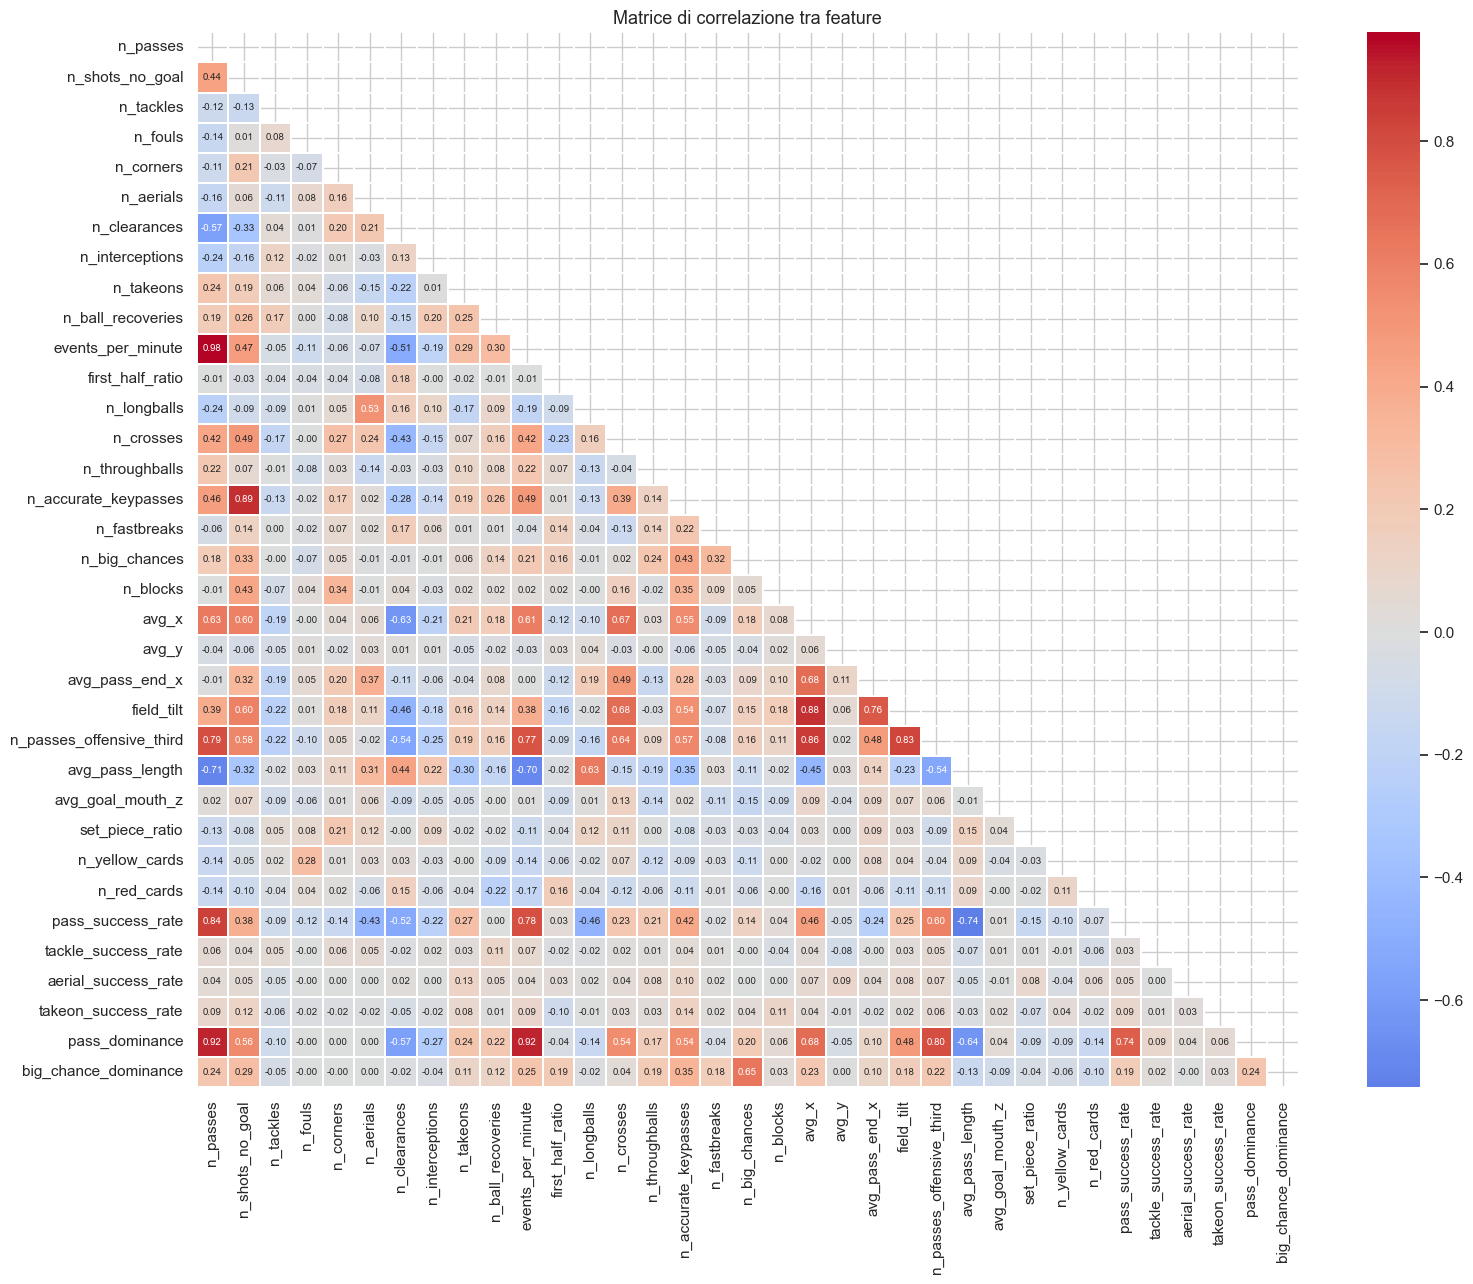

In [19]:
fig, ax = plt.subplots(figsize=(16, 13))
corr = features[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.3, annot_kws={"size": 7})
ax.set_title("Matrice di correlazione tra feature", fontsize=13)
plt.tight_layout()
plt.show()

## Salvataggio `features.parquet`

Il dataset aggregato viene salvato in `data/processed/features.parquet`, caricherà e definirà al suo interno `FEATURE_COLS_ML`, che esclude esplicitamente `n_goals` e `shot_conversion_rate` per prevenire il data leakage nell'addestramento dei classificatori.

In [20]:
# Salvataggio Gold Layer

# Check valori nulli 
null_count = features.isnull().sum().sum()
assert null_count == 0, f"ATTENZIONE: {null_count} null residui nel Gold Layer!"
print(f" Null nel Gold Layer: {null_count} — dataset pronto per ML")

Path('data/processed').mkdir(parents=True, exist_ok=True)
features.to_parquet('data/processed/features.parquet', engine='pyarrow', compression='snappy')

print(f'Dataset Gold salvato correttamente.')
print(f'  Percorso: data/processed/features.parquet')
print(f'  Dimensioni: {features.shape[0]:,} righe x {features.shape[1]} colonne')
print(f'  Colonne: {list(features.columns)}')

 Null nel Gold Layer: 0 — dataset pronto per ML
Dataset Gold salvato correttamente.
  Percorso: data/processed/features.parquet
  Dimensioni: 760 righe x 40 colonne
  Colonne: ['match_id', 'teamId', 'n_passes', 'n_shots_no_goal', 'n_tackles', 'n_fouls', 'n_corners', 'n_aerials', 'n_clearances', 'n_interceptions', 'n_takeons', 'n_ball_recoveries', 'events_per_minute', 'first_half_ratio', 'n_longballs', 'n_crosses', 'n_throughballs', 'n_accurate_keypasses', 'n_fastbreaks', 'n_big_chances', 'n_blocks', 'avg_x', 'avg_y', 'avg_pass_end_x', 'field_tilt', 'n_passes_offensive_third', 'avg_pass_length', 'avg_goal_mouth_z', 'set_piece_ratio', 'n_yellow_cards', 'n_red_cards', 'pass_success_rate', 'tackle_success_rate', 'aerial_success_rate', 'takeon_success_rate', 'goals_scored', 'goals_conceded', 'outcome', 'pass_dominance', 'big_chance_dominance']
